In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [33]:
df = pd.read_csv('Advertising.csv')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


### **EDA**

In [35]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


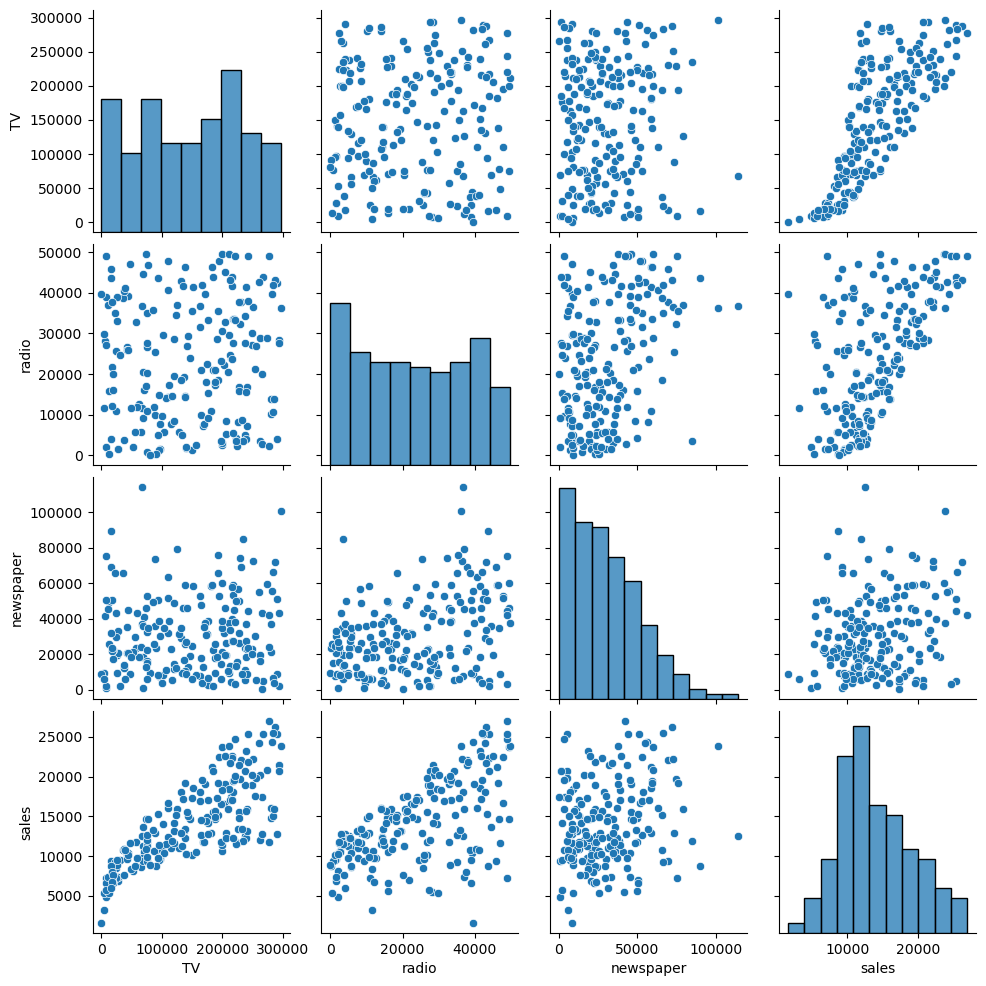

In [36]:
sns.pairplot(df)
plt.show()

In [37]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [38]:
X = df.drop('sales', axis =1)
y = df['sales']

#### **From Preprocessing, import Polynomial Features, which will help us transform our original data set by adding polynomial features**

In [39]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree =2 , include_bias=False)
X_poly = polynomial_converter.fit_transform(X)
X_poly = pd.DataFrame(X_poly)

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test= train_test_split(X_poly, y , test_size= 0.3 , random_state=42)

### **Model fitting on Polynomial Data**

We will go from the equation in the form (show here as if we only had one x feature.)
                       
                       y^ ​= β0​+ β1​x1 + ε
                    
and create more features from the original x feature for  some d degree of polynomial

                       y^​=β0 ​+ β1​X1 + β1​X1^2+ ..........  + βd​Xd^d + ε


Then we can call the linear regression model on it, since in reality, we're just treating these new polynomial features x^2, x^3,......x^d as new features. Obviously we need to be careful about choosing the correct value of d, the degree of the model. Our netric results on the test set will help us with this!

**The other thing to note here is we have multiple X features, not just a single one as in the formula above, so in reality, the PolynomialFeatures will also take interaction terms into accouont for example, if an input sample is two dimensional and of the form [a,b], the degree-2 polynomial features are [a,b, a^2, ab, b^2].**

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
model.intercept_

np.float64(4718.521644892971)

In [43]:
model.coef_

array([ 5.47817248e-02,  1.31121417e-02,  1.08639079e-02, -1.10740276e-07,
        1.08047633e-06, -1.07643423e-07,  3.01913511e-07,  1.75411787e-07,
        1.00748583e-07])

## **Prediction**

In [44]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

## **Evaluation**

In [45]:
model.score(X_train, y_train)   #Train R2

0.9865054729019952

In [46]:
model.score(X_test, y_test)   # Test R2

0.9808386009948892

In [47]:
from sklearn.metrics import mean_squared_error
test_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))
train_RMSE= np.sqrt(mean_squared_error(y_train, train_pred))
print(test_RMSE, train_RMSE)

723.321847418751 595.0712355838925


In [48]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


polynomial_converter = PolynomialFeatures(degree =2 , include_bias=False)

X_poly = polynomial_converter.fit_transform(X)

X_poly = pd.DataFrame(X_poly)

X_train,X_test, y_train, y_test= train_test_split(X_poly, y , test_size= 0.3 , random_state=42)

model = LinearRegression()

model.fit(X_train , y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print(model.score(X_train, y_train))   #Train R2
print(model.score(X_test, y_test))   # Test R2


0.9865054729019952
0.9808386009948892


#### **Comparison with Linear Regression**

**Results on the Test Set (Note: Use the same Random Split to fairly compare!)**

- Multiple Linear Regression:
     - R2 : 0.9
    
- Polynomial 2-degree
     - R2 = 0.98

#### **Choose a Model**

#### **Bias-Variance Tradeoff**

In [49]:
train_rmse_errors=[]
test_rmse_errors = []

for d in range(1, 10):

    polynomial_converter = PolynomialFeatures(degree =d , include_bias=False)

    X_poly = polynomial_converter.fit_transform(X)

    X_poly = pd.DataFrame(X_poly)

    X_train,X_test, y_train, y_test= train_test_split(X_poly, y , test_size= 0.3 , random_state=42)

    model = LinearRegression()

    model.fit(X_train , y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_RMSE = np.sqrt(mean_squared_error(y_train, train_pred))
    train_rmse_errors.append(train_RMSE)

    test_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))
    test_rmse_errors.append(test_RMSE)




    

In [50]:
train_rmse_errors

[np.float64(1574.5968305905444),
 np.float64(595.0712355838925),
 np.float64(468.87581125247334),
 np.float64(585.2862368380606),
 np.float64(644.7600624164446),
 np.float64(841.8774924104519),
 np.float64(949.8928880145319),
 np.float64(1091.8299516871962),
 np.float64(1449.0557031764688)]

In [51]:
test_rmse_errors

[np.float64(1948.5372043446382),
 np.float64(723.321847418751),
 np.float64(539.2383000808851),
 np.float64(880.3953819203689),
 np.float64(1611.937922856158),
 np.float64(6959.812761367436),
 np.float64(120124.51431376163),
 np.float64(106115.24734856312),
 np.float64(1024574.5409450744)]

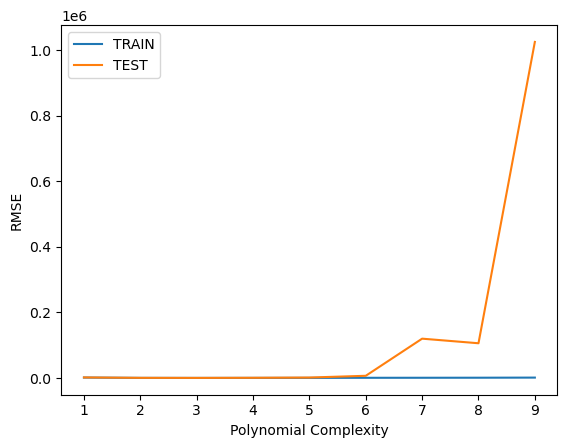

In [52]:
plt.plot(range(1,10), train_rmse_errors, label = 'TRAIN')
plt.plot(range(1, 10), test_rmse_errors, label = 'TEST')
plt.xlabel('Polynomial Complexity')
plt.ylabel('RMSE')
plt.legend()
plt.show()

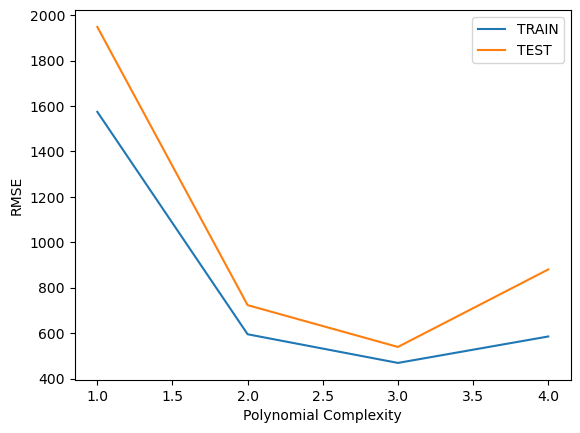

In [53]:
plt.plot(range(1,5), train_rmse_errors[:4], label = 'TRAIN')
plt.plot(range(1,5), test_rmse_errors[:4], label = 'TEST')
plt.xlabel('Polynomial Complexity')
plt.ylabel('RMSE')
plt.legend()
plt.show()

## **Finalizing Model Choice**

There are now 2 things we need to save, the Polynomial Feature creator and  the model itself. Let;s example how we would proceed from here:

1. Choose final parameters based on test metrics
2. Retrain model

In [54]:
final_polynomial_converter = PolynomialFeatures(degree =2 , include_bias=False)

X_poly = final_polynomial_converter.fit_transform(X)

X_poly = pd.DataFrame(X_poly)

X_train,X_test, y_train, y_test= train_test_split(X_poly, y , test_size= 0.3 , random_state=42)

final_model = LinearRegression()

final_model.fit(X_train , y_train)

train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

print('Train R2:', final_model.score(X_train, y_train))   #Train R2
print('Test R2:', final_model.score(X_test, y_test))   # Test R2

Train R2: 0.9865054729019952
Test R2: 0.9808386009948892


## **Deployement**

In [55]:
from joblib import dump

dump(final_model, 'sales_poly_model.jonlib')

['sales_poly_model.jonlib']

In [56]:
dump(final_polynomial_converter, 'poly_converter.joblib')

['poly_converter.joblib']

In [57]:
from joblib import load

In [58]:
loaded_poly = load('poly_converter.joblib')
loaded_model = load('sales_poly_model.jonlib')

#### **Prediction on New Data**

Recall that we will need to **convert** any incoming data to polynomial data, since thta is what our model is trained on. We simply load up our saved converter oject and only call. **transform()** on the new data, since we're not refitting to a new data set.

**Our next ad campaign will have a total spend of 149k on TV, 22k on Radio, and 12k on Newspaper Ads, how many units could we expect to sell as a result of this?**

In [60]:
compaign_poly = loaded_poly.transform([[149000, 22000, 12000]])
loaded_model.predict(compaign_poly)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([14397.56539338])